In [1]:
import pandas as pd
from mpmath.libmp import normalize
from pandas.conftest import ascending
from pygments.styles.dracula import background

In [4]:
def load_dataset():
    return pd.read_csv("YoutubeCommentsDataset.csv")
df = load_dataset()

In [5]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [6]:
df["Sentiment"]

0         neutral
1        negative
2        positive
3        negative
4        positive
           ...   
18403    positive
18404    positive
18405     neutral
18406    positive
18407    positive
Name: Sentiment, Length: 18408, dtype: str

In [7]:
# Changing the sentiment into numbers for model
df["Sentiment"] = df["Sentiment"].map({"positive": 1, "negative": -1, "neutral": 0})


In [8]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,0
1,here in nz 50 of retailers don’t even have con...,-1
2,i will forever acknowledge this channel with t...,1
3,whenever i go to a place that doesn’t take app...,-1
4,apple pay is so convenient secure and easy to ...,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Comment    18364 non-null  str  
 1   Sentiment  18408 non-null  int64
dtypes: int64(1), str(1)
memory usage: 287.8 KB


In [10]:
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [12]:
df[df["Comment"].isna()]

,Comment,Sentiment
602,NaN,-1
716,NaN,0
812,NaN,1
1021,NaN,1
1023,NaN,0
1041,NaN,1
1094,NaN,1
2443,NaN,1
3014,NaN,1
3235,NaN,1


In [13]:
df.dropna(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(490)

In [15]:
df[df.duplicated()]

,Comment,Sentiment
173,from all the stuff mentioned i have the dji mi...,1
518,happy independence day to ukraine and glory t...,-1
847,linus just turn the key lights 180 and bounce ...,1
848,dan continues to be my new favorite he has suc...,1
849,dan managing to set up his soldering station o...,1
...,...,...
18145,explore our free courses with completion certi...,0
18283,thanks for this video very neatly calmly expla...,1
18298,explore our free courses with completion certi...,0
18308,do you want to learn technology from me check ...,0


In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df[(df["Comment"].str.strip()== '')]

,Comment,Sentiment


In [34]:
df["Comment"] = df["Comment"].str.lower()

In [35]:
df[df["Comment"].apply(lambda x: x.endswith(" ") or x.startswith(" "))]

,Comment,Sentiment,Comment,word count
20,linus just turn the key lights 180 and bounce ...,1,linus just turn the key lights 180 and bounce ...,50
65,back in 2018 when john oliver did the episode ...,-1,back in 2018 when john oliver did the episode ...,167
77,i have to say it after watching this video it ...,1,i have to say it after watching this video it ...,52
78,i havent laughed like this for years oh my gos...,1,i havent laughed like this for years oh my gos...,16
93,if the lead singer is bret michaels then im su...,1,if the lead singer is bret michaels then im su...,19
...,...,...,...,...
18250,wow congratulations for starting such an amazi...,1,wow congratulations for starting such an amazi...,8
18278,omg such awesome day to day life examples give...,1,omg such awesome day to day life examples give...,14
18343,amazing explanation i loved the way you taught,1,amazing explanation i loved the way you taught,8
18349,idk if you realise the intensity of positive i...,1,idk if you realise the intensity of positive i...,25


In [21]:
import langdetect

In [22]:
!pip install langdetect


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from langdetect import detect, LangDetectException


def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False


df = df[df["Comment"].apply(is_english)]
df


,Comment,Sentiment,Comment,word count
0,lets not forget that apple pay in 2014 require...,0,lets not forget that apple pay in 2014 require...,57
1,here in nz 50 of retailers don’t even have con...,-1,here in nz 50 of retailers don’t even have con...,29
2,i will forever acknowledge this channel with t...,1,i will forever acknowledge this channel with t...,31
3,whenever i go to a place that doesn’t take app...,-1,whenever i go to a place that doesn’t take app...,83
4,apple pay is so convenient secure and easy to ...,1,apple pay is so convenient secure and easy to ...,26
...,...,...,...,...
18402,back when i was learning to code i didn’t know...,0,back when i was learning to code i didn’t know...,126
18403,i really like the point about engineering tool...,1,i really like the point about engineering tool...,52
18404,i’ve just started exploring this field and thi...,1,i’ve just started exploring this field and thi...,23
18406,hey daniel just discovered your channel a coup...,1,hey daniel just discovered your channel a coup...,16


In [24]:
df.iloc[34]

Comment      guys a quick note that you do not need all the...
Sentiment                                                    0
Comment      guys a quick note that you do not need all the...
Name: 40, dtype: object

In [37]:
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['Comment'].str.contains(url_pattern, regex = True)]
comments_with_urls.head()

,Comment,Sentiment,Comment,word count


In [38]:
comments_with_newline = df[df["Comment"].str.contains('\n')]
comments_with_newline.head()

,Comment,Sentiment,Comment,word count


# EDA




In [39]:
 import matplotlib.pyplot as plt
 import seaborn as sns

<Axes: xlabel='Sentiment', ylabel='count'>

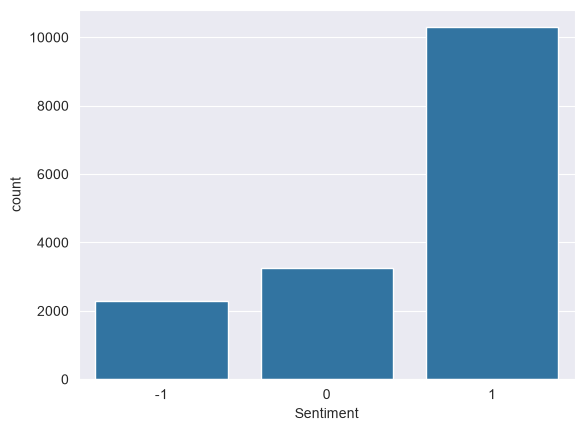

In [40]:
sns.countplot(data=df, x="Sentiment")

## Sentiment Distribution Analysis

This line of code analyzes the distribution of sentiment labels in the dataset:

- **`df['Sentiment']`** — selects the `Sentiment` column from the DataFrame
- **`.value_counts(normalize=True)`** — counts the occurrences of each unique value (`-1`, `0`, `1`) and returns them as **proportions** (fractions summing to 1) instead of raw counts
- **`.mul(100)`** — multiplies each proportion by 100 to convert to **percentages**
- **`.round(2)`** — rounds each percentage to **2 decimal places**

### Example Output:
| Sentiment | Percentage |
|-----------|------------|
| 1 (positive) | 45.32 |
| 0 (neutral)  | 30.15 |
| -1 (negative)| 24.53 |

This gives a quick overview of **how balanced** the dataset is across the three sentiment classes.


In [41]:
df['word count'] = df["Comment"].apply(lambda x: len(x.split()))

In [42]:
df.sample(5)

,Comment,Sentiment,Comment,word count
14534,on the stanford channel i obsessively watched ...,1,on the stanford channel i obsessively watched ...,11
6787,2021 will mark the 200th birthday of this lege...,1,2021 will mark the 200th birthday of this lege...,24
14274,editor how much fake do you want physics yes,0,editor how much fake do you want physics yes,9
13461,youre so cool i really look up to you because ...,1,youre so cool i really look up to you because ...,61
2295,this is crazy i learnt all of these for years ...,1,this is crazy i learnt all of these for years ...,32


In [43]:
df.head(5)

,Comment,Sentiment,Comment,word count
0,lets not forget that apple pay in 2014 require...,0,lets not forget that apple pay in 2014 require...,57
1,here in nz 50 of retailers don’t even have con...,-1,here in nz 50 of retailers don’t even have con...,29
2,i will forever acknowledge this channel with t...,1,i will forever acknowledge this channel with t...,31
3,whenever i go to a place that doesn’t take app...,-1,whenever i go to a place that doesn’t take app...,83
4,apple pay is so convenient secure and easy to ...,1,apple pay is so convenient secure and easy to ...,26


In [44]:
df["word count"].describe()

count    15823.000000
mean        35.136384
std         47.172707
min          1.000000
25%         14.000000
50%         23.000000
75%         40.000000
max       1353.000000
Name: word count, dtype: float64

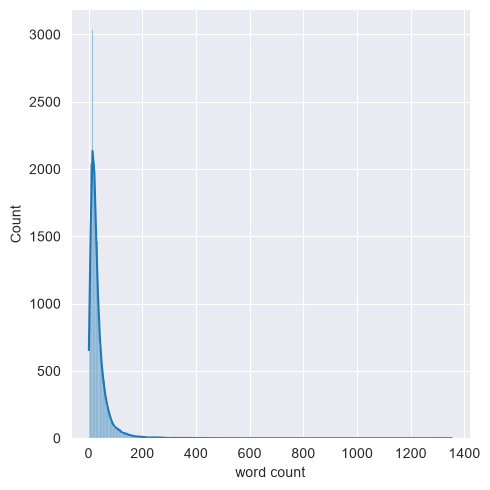

In [47]:
sns.displot(df["word count"], kde=True)

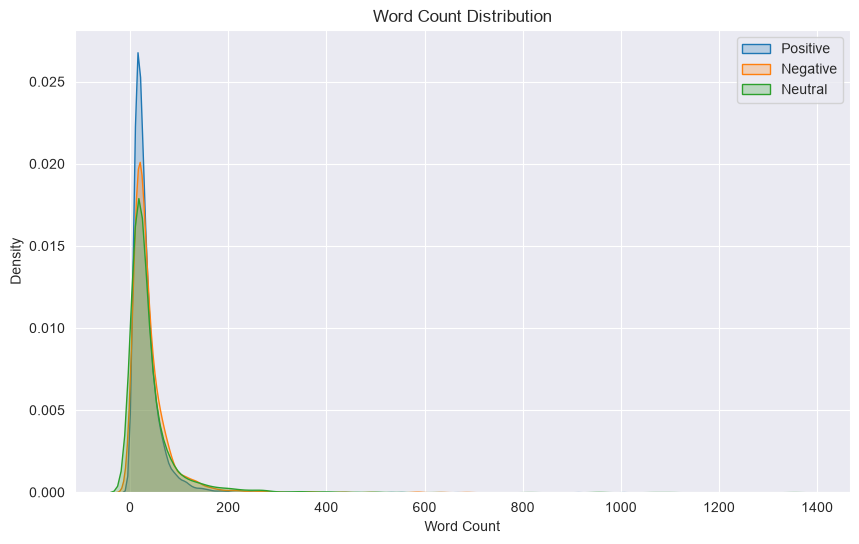

In [50]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df["Sentiment"] == 1]["word count"], label="Positive", fill = True)
sns.kdeplot(df[df["Sentiment"] == -1]["word count"], label="Negative", fill = True)
sns.kdeplot(df[df["Sentiment"] == 0]["word count"], label="Neutral", fill = True)
plt.legend()
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.show()

<Axes: ylabel='word count'>

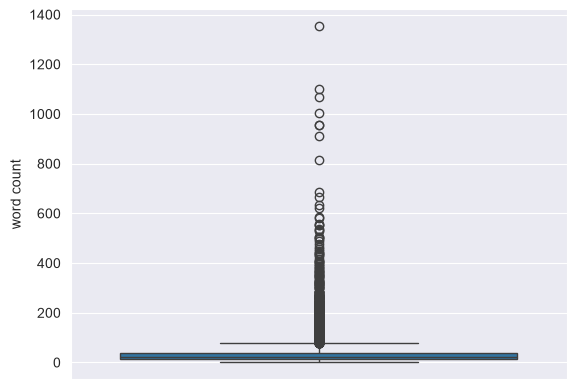

In [52]:
sns.boxplot(df["word count"], orient="v")

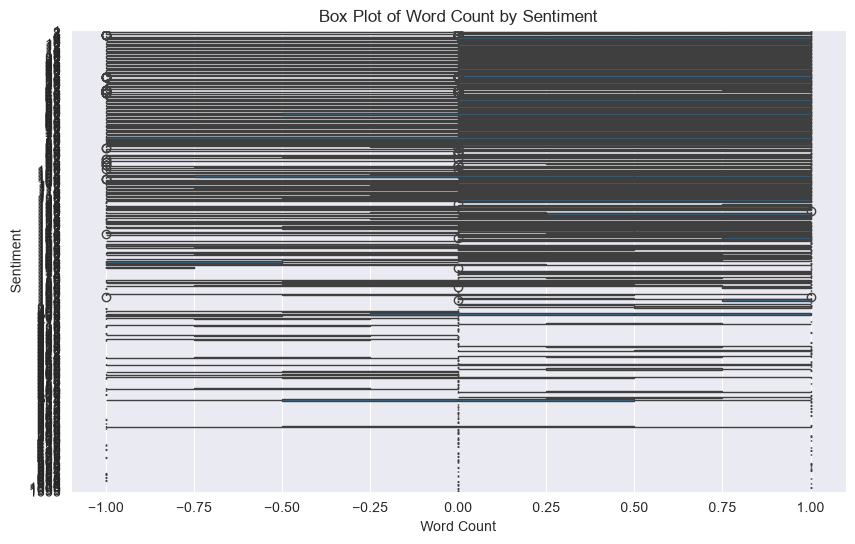

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="Sentiment", y="word count", orient="h")
plt.title('Box Plot of Word Count by Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Sentiment')
plt.show()

<Axes: xlabel='Sentiment', ylabel='word count'>

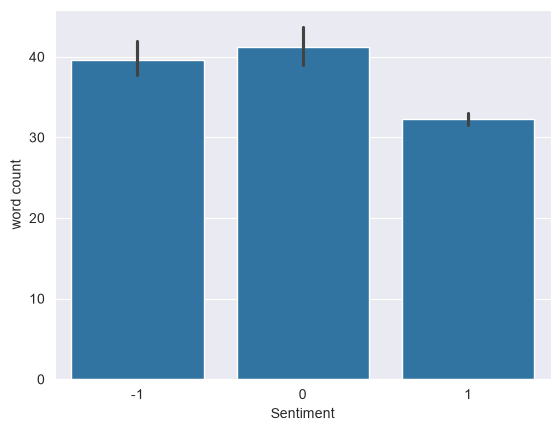

In [56]:
sns.barplot(data=df, x="Sentiment", y="word count", orient="v")

In [58]:
from nltk.corpus import  stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['num_stop_words'] = df["Comment"].apply(lambda x:len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [59]:
df.sample(5)

,Comment,Sentiment,Comment,word count,num_stop_words
7645,i wish i still had zoom calls to randomly see ...,1,i wish i still had zoom calls to randomly see ...,16,6
8319,this is so satisfying especially how much she ...,1,this is so satisfying especially how much she ...,14,6
8926,loving the vibe of this thank you this is now ...,1,loving the vibe of this thank you this is now ...,13,8
10996,albino snakes are probably one of the most com...,0,albino snakes are probably one of the most com...,77,30
9654,i’ve commented on a previous video he put out ...,1,i’ve commented on a previous video he put out ...,67,30


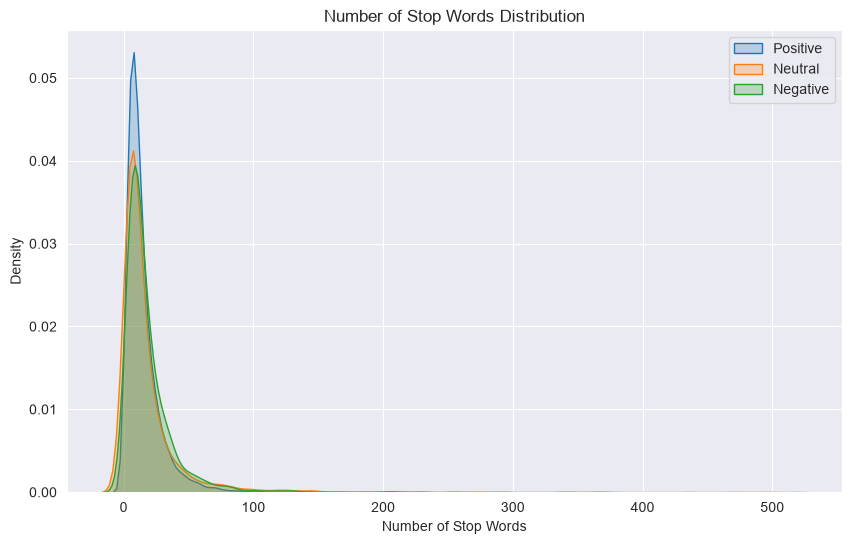

In [60]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['Sentiment']== 1]['num_stop_words'], label = 'Positive',  fill=True)
sns.kdeplot(df[df["Sentiment"]== 0]['num_stop_words'], label = 'Neutral', fill=True)
sns.kdeplot(df[df["Sentiment"]==-1]['num_stop_words'], label = 'Negative', fill=True)
plt.legend()
plt.title("Number of Stop Words Distribution")
plt.xlabel("Number of Stop Words")
plt.ylabel("Density")
plt.show()


<Axes: xlabel='Sentiment', ylabel='num_stop_words'>

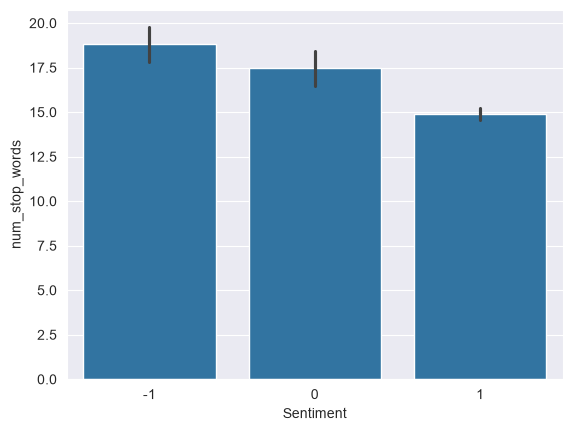

In [62]:
sns.barplot(data=df, x="Sentiment", y="num_stop_words")

C:\Users\HP\AppData\Local\Temp\ipykernel_57168\4293578462.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y= 'stop_word' , palette='viridis', orient='h')


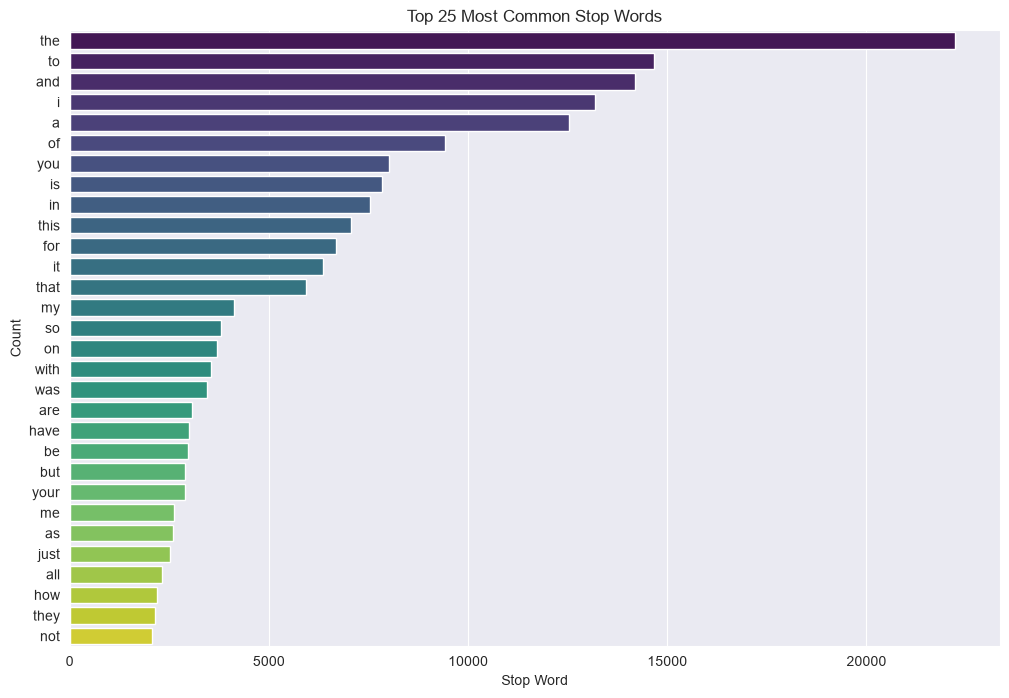

In [67]:
from collections import Counter
all_stop_words = [word for comment in df["Comment"] for word in comment.split() if word in stop_words]

most_common_stop_words = Counter(all_stop_words).most_common(30)

top_25_df = pd.DataFrame(most_common_stop_words, columns = ['stop_word', 'count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df, x='count', y= 'stop_word' , palette='viridis', orient='h')
plt.title("Top 25 Most Common Stop Words")
plt.xlabel("Stop Word")
plt.ylabel("Count")
plt.show()


In [68]:
df['num_chars'] = df["Comment"].apply(len)
df.head(5)

,Comment,Sentiment,Comment,word count,num_stop_words,num_chars
0,lets not forget that apple pay in 2014 require...,0,lets not forget that apple pay in 2014 require...,57,23,317
1,here in nz 50 of retailers don’t even have con...,-1,here in nz 50 of retailers don’t even have con...,29,10,163
2,i will forever acknowledge this channel with t...,1,i will forever acknowledge this channel with t...,31,16,183
3,whenever i go to a place that doesn’t take app...,-1,whenever i go to a place that doesn’t take app...,83,34,450
4,apple pay is so convenient secure and easy to ...,1,apple pay is so convenient secure and easy to ...,26,12,135


In [69]:
df['num_chars'].describe()

count    15823.000000
mean       188.603805
std        260.878456
min          4.000000
25%         73.000000
50%        121.000000
75%        214.000000
max       7847.000000
Name: num_chars, dtype: float64

In [71]:
from collections import Counter
all_text = ' '.join(df['Comment'])
char_freq = Counter(all_text)
char_freq_df = pd.DataFrame(char_freq.items(), columns = ['char','frequency']).sort_values(by='frequency',ascending = False)


In [75]:
char_freq_df.tail(10)

,char,frequency
126,편,1
128,점,1
135,양,1
138,못,1
413,́,1
414,‿,1
415,̀,1
416,â,1
458,ö,1
454,ê,1


In [76]:
df['num_punct_chars'] = df['Comment'].apply(
    lambda x: sum([1 for char in x if char in '.,;!?()[]{}"\'\\/:@#$%^&*~`'])
)
df.sample(5)

,Comment,Sentiment,Comment,word count,num_stop_words,num_chars,num_punct_chars
14112,this is the kind of physics i understand it ma...,0,this is the kind of physics i understand it ma...,33,21,164,0
14347,can someone explain something to me not a trai...,0,can someone explain something to me not a trai...,40,20,224,0
3444,i enjoyed it thank you any others kind of such...,1,i enjoyed it thank you any others kind of such...,20,10,113,0
2210,how are you all doing today,0,how are you all doing today,6,5,27,0
2845,i can’t believe i learned this in less than a ...,1,i can’t believe i learned this in less than a ...,43,24,191,0


In [77]:
df['num_punct_chars'].describe()

count    15823.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punct_chars, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_57168\2746567519.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y= 'bigram' , palette='magma')


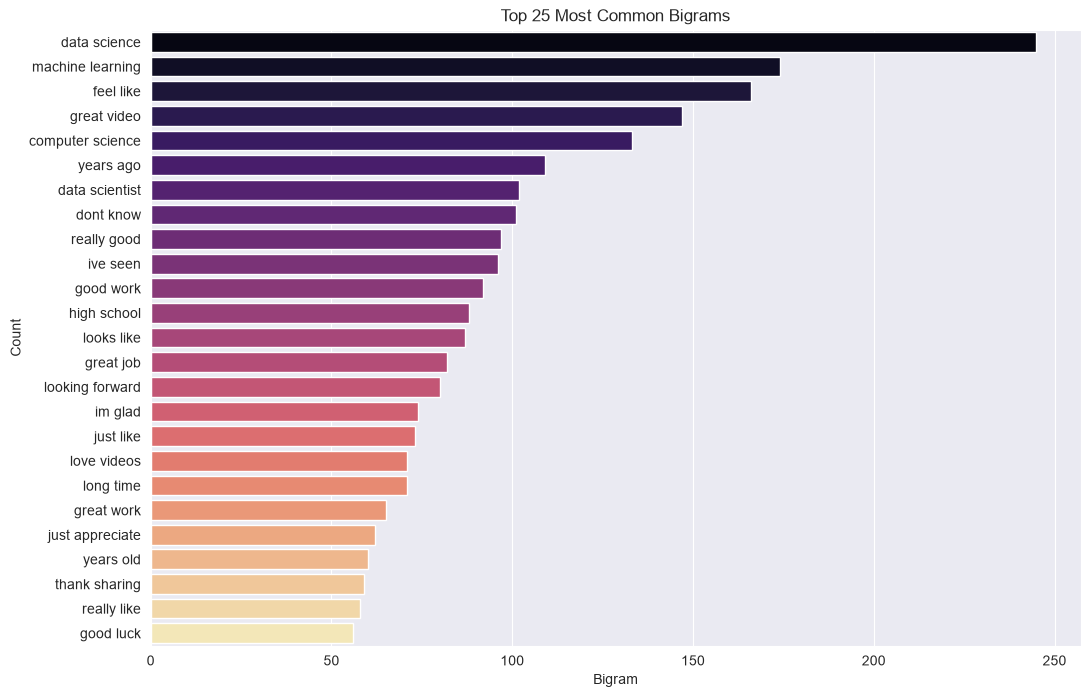

In [81]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words = 'english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word , idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

top_25_bigrams = get_top_ngrams(df['Comment'], n=25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns = ['bigram', 'count'])
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df, x='count', y= 'bigram' , palette='magma')
plt.title("Top 25 Most Common Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Count")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_57168\714182255.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y= 'trigram' , palette='magma')


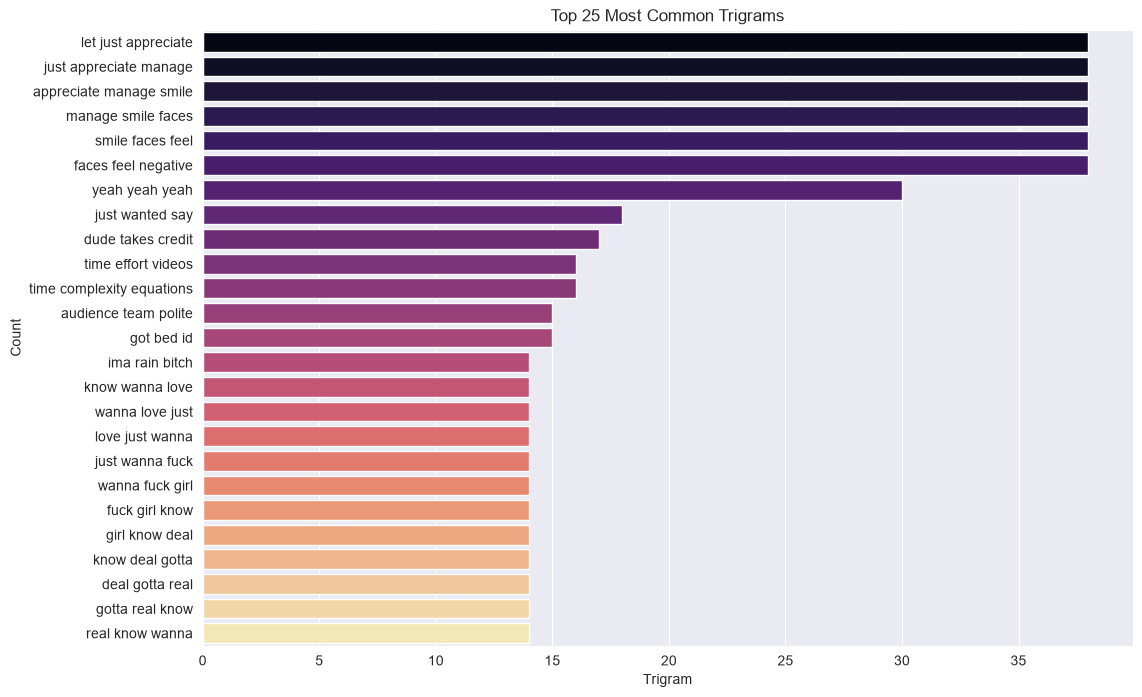

In [82]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words = 'english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word , idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

top_25_trigrams = get_top_ngrams(df['Comment'], n=25)
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns = ['trigram', 'count'])
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_trigrams_df, x='count', y= 'trigram' , palette='magma')
plt.title("Top 25 Most Common Trigrams")
plt.xlabel("Trigram")
plt.ylabel("Count")
plt.show()

In [83]:
import re

df["Comment"] = df["Comment"].apply(lambda x: re.sub(r'[^A-Za-z0-9\s]', '', str(x)))


In [84]:
from collections import Counter
all_text = ' '.join(df['Comment'])
char_freq = Counter(all_text)
char_freq_df = pd.DataFrame(char_freq.items(), columns = ['char','frequency']).sort_values(by='frequency',ascending = False)

In [85]:
char_freq_df.tail(10)

,char,frequency
15,2,4527
34,3,3485
28,5,3138
18,4,2891
27,z,2652
19,q,2133
35,6,1512
36,7,1306
32,8,1251
33,9,1151


In [87]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')) - {'not', 'however', 'but', 'yet', 'no'}

df["Comment"] = df["Comment"].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)


In [88]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
df['Comment'] = df['Comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word  in x.split()])
)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


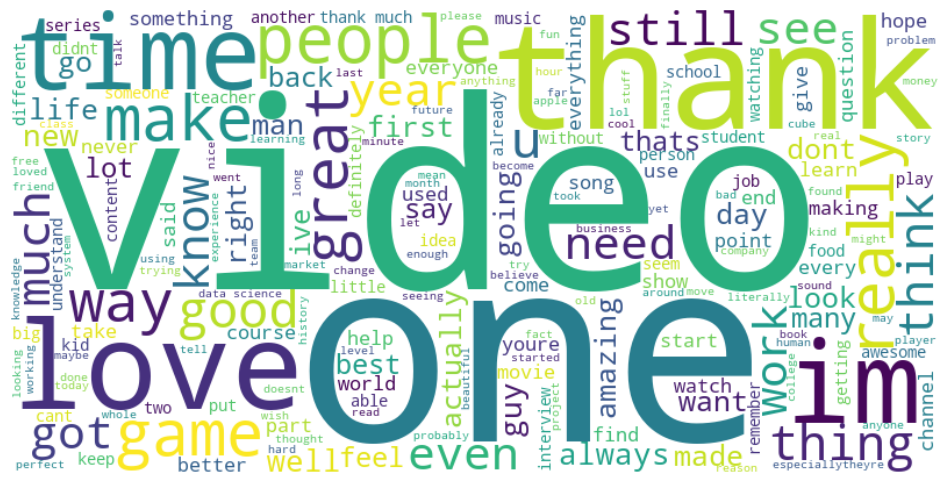

In [92]:
from wordcloud import WordCloud

def plot_word_cloud(text):
    wordcloud = WordCloud(width = 800 , height = 400 , background_color = 'white').generate(' '.join(text))
    plt.figure(figsize=(12,8))
    plt.imshow(wordcloud , interpolation = 'bilinear')
    plt.axis('off')
    plt.show()
plot_word_cloud(df['Comment'])

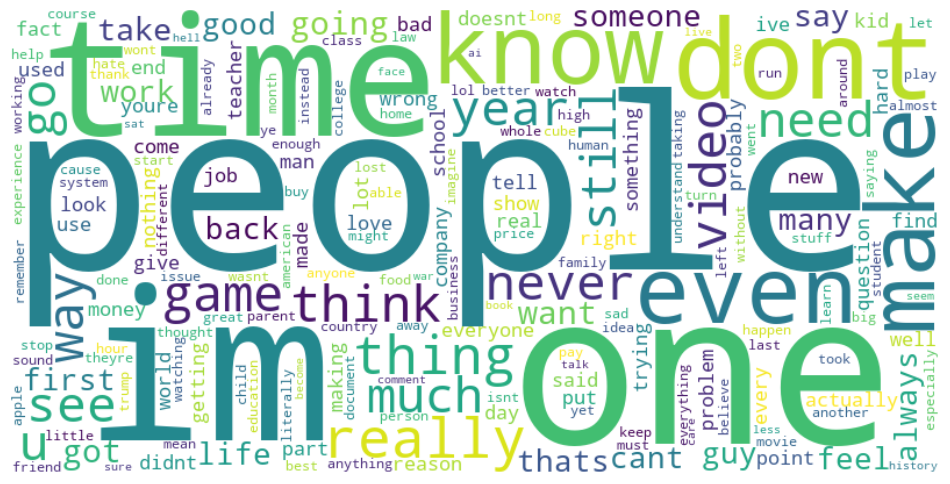

In [95]:
from wordcloud import WordCloud

def plot_word_cloud(text):
    wordcloud = WordCloud(width = 800 , height = 400 , background_color = 'white').generate(' '.join(text))
    plt.figure(figsize=(12,8))
    plt.imshow(wordcloud , interpolation = 'bilinear')
    plt.axis('off')
    plt.show()
plot_word_cloud(df[df['Sentiment']==-1]['Comment'])

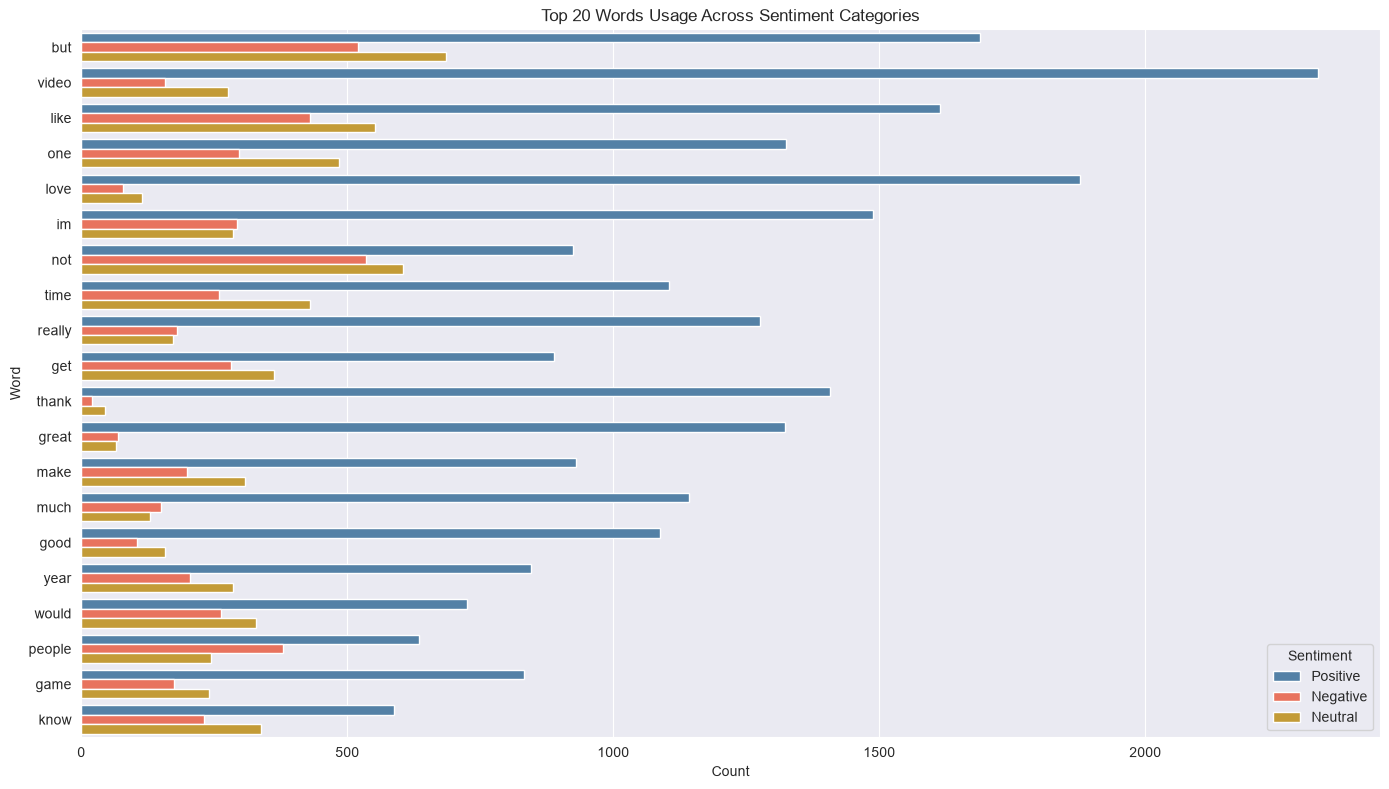

In [98]:
def plot_top_n_words_by_cateogry(df, category_col='Sentiment', text_col='Comment', n=20):
    categories = df[category_col].unique()
    for category in categories:
        subset = df[df[category_col] == category][text_col]
        all_words = ' '.join(subset).split()
        word_counts = Counter(all_words)
        top_n = word_counts.most_common(n)
        top_n_df = pd.DataFrame(top_n, columns=['word', 'count'])



    # Collect top N words across all comments
    all_words_global = ' '.join(df[text_col]).split()
    global_top_n = [word for word, _ in Counter(all_words_global).most_common(n)]

    # Build a DataFrame with counts per sentiment for each top word
    sentiment_label_map = {1: 'Positive', -1: 'Negative', 0: 'Neutral'}
    rows = []
    for word in global_top_n:
        for sentiment_val, sentiment_label in sentiment_label_map.items():
            if sentiment_val in df[category_col].values:
                subset_words = ' '.join(df[df[category_col] == sentiment_val][text_col]).split()
                count = subset_words.count(word)
                rows.append({'word': word, 'sentiment': sentiment_label, 'count': count})

    cross_df = pd.DataFrame(rows)

    plt.figure(figsize=(14, 8))
    sns.barplot(data=cross_df, x='count', y='word', hue='sentime pnt',
                palette={'Positive': 'steelblue', 'Negative': 'tomato', 'Neutral': 'goldenrod'})
    plt.title(f'Top {n} Words Usage Across Sentiment Categories')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()


plot_top_n_words_by_cateogry(df, n=20)
